In [2]:
import seaborn as sns
import numpy as np
import pandas as pd

In [3]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
pf = df[df['species']!='setosa']

In [8]:
pf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [9]:
pf['species'] = pf['species'].map({'versicolor':0,'virginica':1})

C:\Users\abhin\AppData\Local\Temp\ipykernel_11468\4043173178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pf['species'] = pf['species'].map({'versicolor':0,'virginica':1})


In [10]:
x=pf.iloc[:,:-1]
y=pf.iloc[:,-1]

In [11]:
x

,sepal_length,sepal_width,petal_length,petal_width
50,7.0,3.2,4.7,1.4
51,6.4,3.2,4.5,1.5
52,6.9,3.1,4.9,1.5
53,5.5,2.3,4.0,1.3
54,6.5,2.8,4.6,1.5
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [12]:
y

50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: species, Length: 100, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [15]:
from sklearn.model_selection import GridSearchCV
param = {'penalty':['l1','l2','elasticnet'],'C':[1,2,3,4,5,6,7,10,20,30,50,60,100], 'max_iter':[100,200,300]}

In [16]:
classifier_regressor = GridSearchCV(classifier,param_grid=param,cv=5,scoring='accuracy',verbose=3)

In [17]:
classifier_regressor.fit(x_train,y_train)

Fitting 5 folds for each of 117 candidates, totalling 585 fits
[CV 1/5] END .......C=1, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=1, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=1, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .......C=1, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END .......C=1, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END .....C=1, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=1, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=1, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=1, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=1, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=1, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=1, max_iter=100, penalty=elast

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 5/5] END .....C=1, max_iter=300, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=1, max_iter=300, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=1, max_iter=300, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=1, max_iter=300, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=1, max_iter=300, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=1, max_iter=300, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=2, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=2, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=2, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .......C=2, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END .......C=2, max_iter=100, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END .....C=2, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=2, 

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 1/5] END .....C=3, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=3, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=3, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=3, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=3, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=3, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=3, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=3, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=3, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=3, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=3, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=3, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=3

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 1/5] END .....C=4, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=4, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=4, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=4, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=4, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=4, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=4, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=4, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=4, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=4, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=4, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=4, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=4

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 1/5] END .....C=5, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=5, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=5, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=5, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=5, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=5, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=5, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=5, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=5, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=5, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=5, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=5, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=5

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 2/5] END .....C=6, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=6, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=6, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=6, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=6, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=6, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=6, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=6, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=6, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=6, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=6, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=6, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .......C=6

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 2/5] END .....C=7, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END .....C=7, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=7, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END .....C=7, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=7, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=7, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=7, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=7, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=7, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .......C=7, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .......C=7, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .......C=7, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .......C=7

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 2/5] END ....C=10, max_iter=100, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END ....C=10, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END ....C=10, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ....C=10, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=10, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=10, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=10, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=10, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=10, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END ......C=10, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END ......C=10, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END ......C=10, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .....

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 3/5] END ....C=20, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END ....C=20, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ....C=20, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=20, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=20, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=20, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=20, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=20, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END ......C=20, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END ......C=20, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END ......C=20, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END ......C=20, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END .....

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 4/5] END ....C=30, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ....C=30, max_iter=100, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=30, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=30, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=30, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=30, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=30, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END ......C=30, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END ......C=30, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END ......C=30, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END ......C=30, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END ......C=30, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END ....C

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 4/5] END C=50, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=50, max_iter=100, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END ......C=50, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END ......C=50, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END ......C=50, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END ......C=50, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END ......C=50, max_iter=200, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END ....C=50, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END ....C=50, max_iter=200, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END ....C=50, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END ....C=50, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ....C=50, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=50, max_i

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 1/5] END ....C=60, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 2/5] END ....C=60, max_iter=200, penalty=l2;, score=0.867 total time=   0.0s
[CV 3/5] END ....C=60, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 4/5] END ....C=60, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ....C=60, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=60, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=60, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=60, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=60, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=60, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END ......C=60, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END ......C=60, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .....

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

[CV 4/5] END ...C=100, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 5/5] END ...C=100, max_iter=200, penalty=l2;, score=1.000 total time=   0.0s
[CV 1/5] END C=100, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 2/5] END C=100, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 3/5] END C=100, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 4/5] END C=100, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 5/5] END C=100, max_iter=200, penalty=elasticnet;, score=nan total time=   0.0s
[CV 1/5] END .....C=100, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 2/5] END .....C=100, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 3/5] END .....C=100, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 4/5] END .....C=100, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 5/5] END .....C=100, max_iter=300, penalty=l1;, score=nan total time=   0.0s
[CV 1/5] END 

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 2, ...], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [18]:
print(classifier_regressor.best_params_)

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}


In [19]:
print(classifier_regressor.best_score_)

0.9733333333333334


In [20]:
y_pred = classifier_regressor.predict(x_test)

In [21]:
y_pred

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1])

In [22]:
from sklearn.metrics import accuracy_score,classification_report

In [23]:
score = accuracy_score(y_test,y_pred)
print(score)

0.92


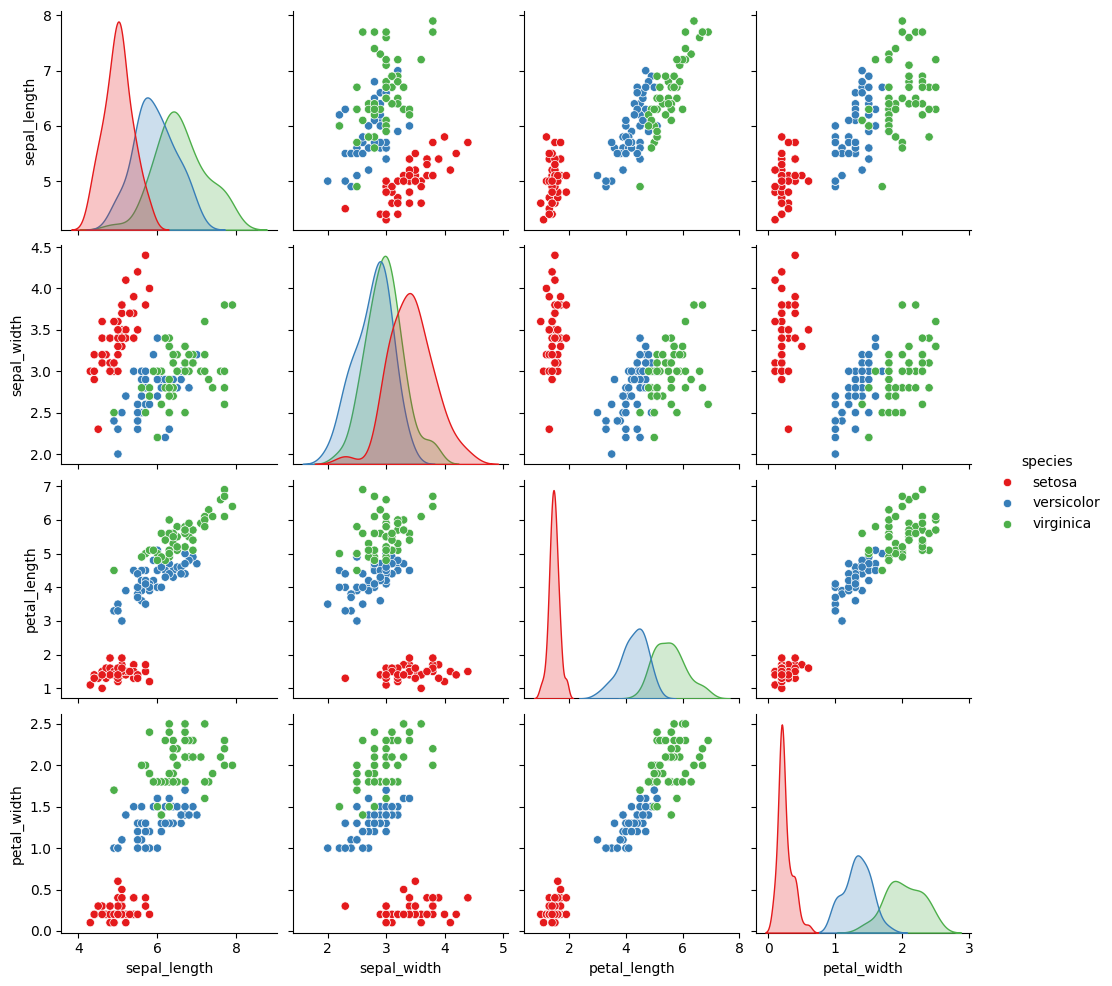

In [24]:
sns.pairplot(df,hue='species',palette='Set1')

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.91      0.91      0.91        11

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25



In [26]:
df.corr

<bound method DataFrame.corr of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>